# Lesson 7. Clustering

Date: 26.05.2026\
Author: *Andrey Zakharov*\
Extended by: *Matvey Bakshuk, FCS HSE*

## 1. Intro

So far in the course we have always had a **target variable** – a label or a number we wanted to predict. **Clustering** is the canonical unsupervised task: we are given only the features $X$ and asked to split the data into groups (**clusters**) such that points inside a cluster are similar and points in different clusters are dissimilar.

Another unsupervised task is **dimensionality reduction** (e.g. PCA, t-SNE, UMAP): it also has no target, but it produces a *new representation* of the data, not group labels. The two are often combined: project to a lower-dimensional space, then cluster – exactly what we will do at the end of this lesson on the Samsung activity-recognition dataset.

For a taxonomy of clustering methods see the [scikit-learn user guide](https://scikit-learn.org/stable/modules/clustering.html). Today we cover three families:

- **Centroid-based** (K-Means) – every point is assigned to the nearest of K representative points (centroids).
- **Connectivity-based** (Agglomerative hierarchical) – bottom-up merging by distance.
- **Density-based** (DBSCAN) – dense regions vs noise, no fixed K.

The final section is on **evaluation**: with no ground truth, how do we even tell whether a clustering is "good"?

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("ignore")
%matplotlib inline

sns.set(style="darkgrid")

## 2. K-Means

K-Means is the most widely used clustering algorithm. It splits $n$ points into $K$ clusters by placing $K$ centroids and assigning each point to its nearest centroid. The **centroid** of a cluster is just the coordinate-wise mean of the points assigned to it.

### Objective

K-Means minimises the **within-cluster sum of squares** (WCSS, also called *inertia*):

$$\text{WCSS} = \sum_{k=1}^{K}\sum_{x_i \in C_k}\|x_i - \mu_k\|^2$$

where $C_k$ is the set of points in cluster $k$ and $\mu_k$ is its centroid. This is exactly what `KMeans.inertia_` returns in sklearn.

### Algorithm (Lloyd's algorithm)

1. Choose $K$.
2. Initialise $K$ centroids (`k-means++` is the sklearn default and is much better than uniform random – see the note below).
3. **Assign**: each point goes to the nearest centroid (Euclidean distance).
4. **Update**: recompute each centroid as the mean of its assigned points.
5. Repeat steps 3–4 until assignments stop changing (or `max_iter` is hit).

> **Why `k-means++` initialization?** If you place the initial centroids purely at random, two of them can land close to each other – and then K-Means converges to a partition with one "empty" region and one over-crowded one. **k-means++** (Arthur & Vassilvitskii, 2007) fixes this by spreading the initial centroids out: each new centroid is sampled preferentially from points that are *far* from the already-chosen ones. In the original paper this gave roughly a 2× speed-up and on some datasets dramatically lower final inertia compared to uniform-random initialisation.

![kmeans animation](https://248006.selcdn.ru/public/DS.%20Block%202.%20M7/kmeans8.gif)

### Things to remember

- **Standardise the features** before clustering – distances are not scale-invariant.
- **Initialisation matters**: re-run with several seeds via `n_init=10` (or `n_init='auto'` in sklearn ≥ 1.4) – the best run by inertia is kept.
- **You must pre-specify $K$** – we'll see how to choose it below.
- For very large datasets use **`MiniBatchKMeans`** (covered in Section 6).
- K-Means assumes clusters are **convex and roughly isotropic** (similar variance in all directions). It fails on moons, spirals, or strongly unequal cluster sizes.

### A small demo: three Gaussian blobs

We generate 150 points from three Gaussian blobs and let K-Means recover them.

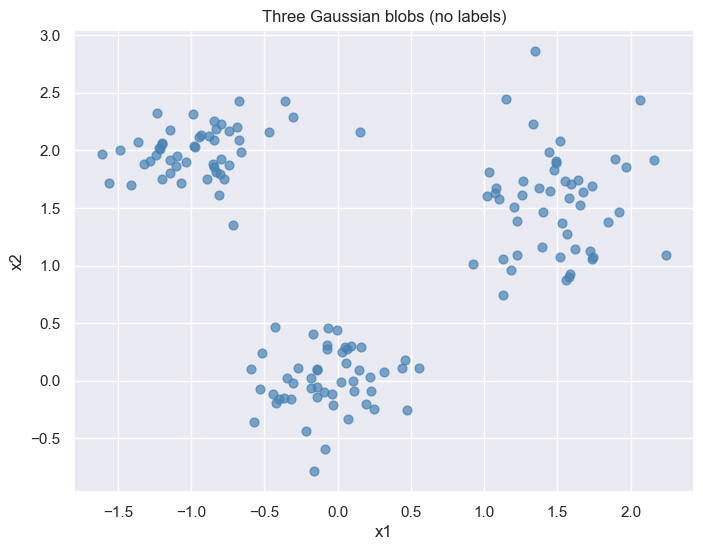

In [34]:
np.random.seed(seed=42)

X = np.zeros((150, 2))
X[:50, 0] = np.random.normal(loc=0.0, scale=.3, size=50)
X[:50, 1] = np.random.normal(loc=0.0, scale=.3, size=50)
X[50:100, 0] = np.random.normal(loc=1.5, scale=.3, size=50)
X[50:100, 1] = np.random.normal(loc=1.5, scale=.5, size=50)
X[100:150, 0] = np.random.normal(loc=-1.0, scale=.3, size=50)
X[100:150, 1] = np.random.normal(loc=2.0, scale=.2, size=50)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=40, color='steelblue', alpha=0.7)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Three Gaussian blobs (no labels)')
plt.show()

In [35]:
from sklearn.cluster import KMeans

# n_init=10 – run from 10 different random initialisations and keep the best.
# random_state=0 – fix the random seed so the result is exactly reproducible
#                  (same number every time the cell is run).
kmeans = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X)
print('First 10 cluster labels:', kmeans.labels_[:10])
print('Inertia (WCSS):         ', round(kmeans.inertia_, 3))

First 10 cluster labels: [2 2 2 2 2 2 2 2 2 2]
Inertia (WCSS):          29.094


**Visualise the partition** with the recovered centroids.

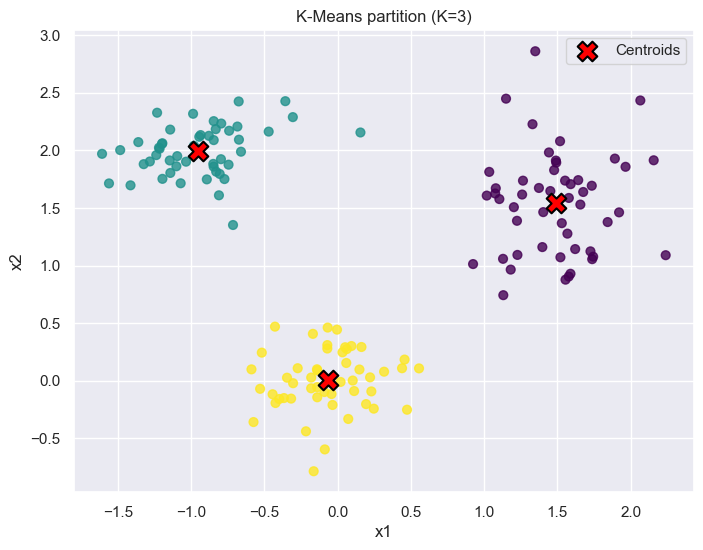

In [36]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['x1', 'x2'])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=40, cmap='viridis', alpha=0.8)
plt.scatter(centers.x1, centers.x2, s=200, color='red', marker='X',
            edgecolor='black', linewidth=1.5, label='Centroids')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('K-Means partition (K=3)')
plt.legend()
plt.show()

**Check cluster sizes.** Strong imbalance with default settings is usually a sign of outliers or wrong $K$.

In [37]:
from collections import Counter
Counter(kmeans.labels_)

Counter({np.int32(2): 50, np.int32(0): 50, np.int32(1): 50})

### How to choose $K$? The elbow method

For each candidate $K$ we fit K-Means and record the inertia. Inertia is monotonically decreasing in $K$ (more clusters → smaller WCSS), so we look for the **elbow** – the point where the marginal gain from adding one more cluster drops sharply.

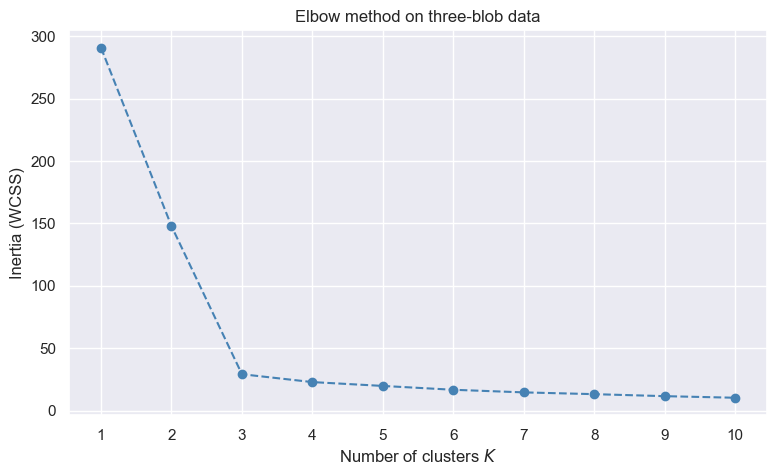

In [38]:
wcss = []
ks = range(1, 11)
for k in ks:
    km = KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(ks), wcss, marker='o', linestyle='--', color='steelblue')
plt.xlabel('Number of clusters $K$')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow method on three-blob data')
plt.xticks(list(ks))
plt.grid(True)
plt.show()

The curve bends sharply at $K=3$, matching the true number of generating blobs. In practice the elbow is rarely this clean – the **silhouette score** (Section 5) usually gives a more decisive answer, especially when several $K$ look plausible.

> **Why visualising inertia alone is not enough**: inertia can be made arbitrarily small by setting $K=n$ (each point its own cluster, WCSS = 0). The elbow is a *heuristic* compromise, not an objective optimum.

### When K-Means breaks

K-Means assumes clusters are convex (roughly spherical) and have similar variance. Two non-Gaussian datasets to keep in mind:

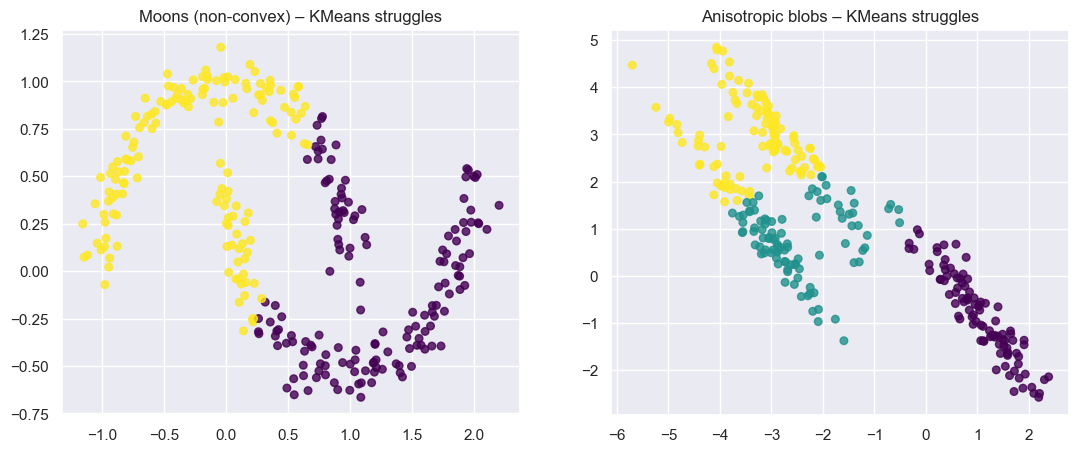

In [39]:
from sklearn.datasets import make_moons, make_blobs

moons, _ = make_moons(n_samples=300, noise=0.08, random_state=0)
aniso_X, _ = make_blobs(n_samples=300, random_state=170)
aniso_X = aniso_X @ np.array([[0.6, -0.6], [-0.4, 0.8]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, title in zip(
    axes,
    [moons, aniso_X],
    ['Moons (non-convex)', 'Anisotropic blobs']
):
    km = KMeans(n_clusters=2 if 'Moons' in title else 3, n_init=10, random_state=0).fit(data)
    ax.scatter(data[:, 0], data[:, 1], c=km.labels_, cmap='viridis', s=30, alpha=0.8)
    ax.set_title(f'{title} – KMeans struggles')
plt.show()

On moons K-Means splits the data with a straight line because the regions it creates around each centroid are always convex. On anisotropic blobs it ignores the elongated shape. **DBSCAN handles moons well, and spectral clustering handles anisotropy.** We will see DBSCAN below.

## 3. Hierarchical clustering

Hierarchical clustering builds a tree of clusters – a **dendrogram** – and lets us cut it at any level to obtain a partition. Two flavours:

- **Agglomerative** (bottom-up): start with every point as its own cluster, repeatedly merge the two closest clusters.
- **Divisive** (top-down): start with one cluster of all points, repeatedly split.

The agglomerative variant is overwhelmingly more common and is what `sklearn.cluster.AgglomerativeClustering` implements.

### Algorithm (agglomerative)

1. Every point starts as its own cluster.
2. Compute pairwise distances between all clusters.
3. **Merge** the two clusters with the smallest distance into one.
4. Repeat 2–3 until a single cluster remains (or until you reach the requested $K$).

### Linkage criteria

The cluster-to-cluster distance is defined by the **linkage** rule:

- **Single linkage** – distance between the *closest* pair of points across the two clusters. Tends to "chain" points together and is sensitive to outliers.
- **Complete linkage** – distance between the *farthest* pair. Produces compact, tight clusters.
- **Average linkage** – mean of all pairwise distances between the two clusters.
- **Ward** (sklearn default) – picks the pair of clusters whose merging causes the smallest increase in *total within-cluster spread*. Tends to produce balanced, roughly round clusters; works only with Euclidean distance.

### How many clusters?

Look at the dendrogram and **cut at a height where vertical jumps are large** – that's where merging produces a steep loss of similarity. No need to pre-specify $K$ before fitting.

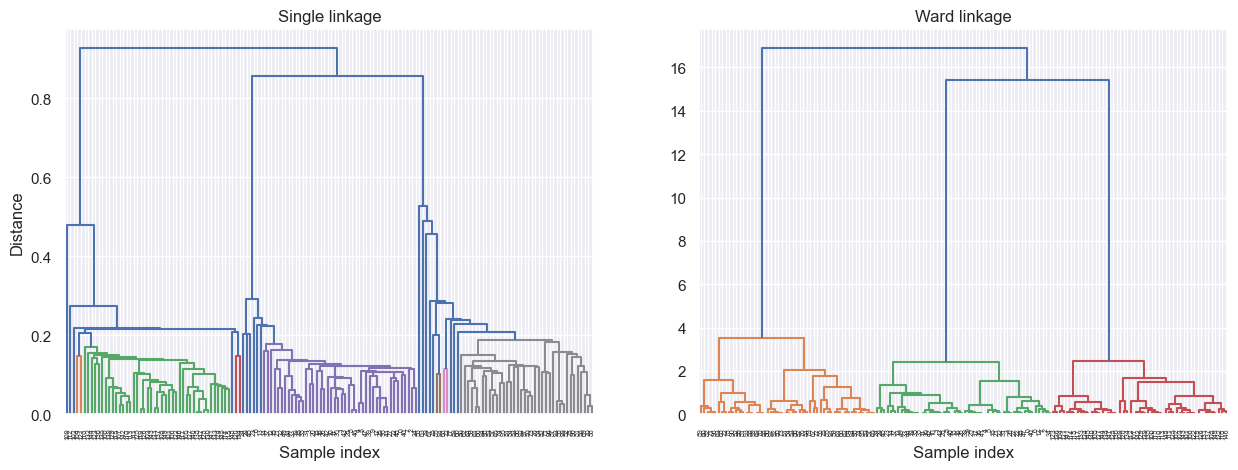

In [40]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Two linkage rules, two very different trees
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

Z_single = linkage(X, method='single', metric='euclidean')
dendrogram(Z_single, ax=axes[0], color_threshold=0.2)
axes[0].set_title('Single linkage')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Distance')

Z_ward = linkage(X, method='ward', metric='euclidean')
dendrogram(Z_ward, ax=axes[1])
axes[1].set_title('Ward linkage')
axes[1].set_xlabel('Sample index')

plt.show()

Ward's dendrogram shows three clearly distinct sub-trees that join at heights ≈ 6 and ≈ 16 – these big vertical gaps suggest $K=3$. Single linkage's tree is much more "chained" and visually harder to read; the same data, different linkage, gives a very different impression of cluster structure.

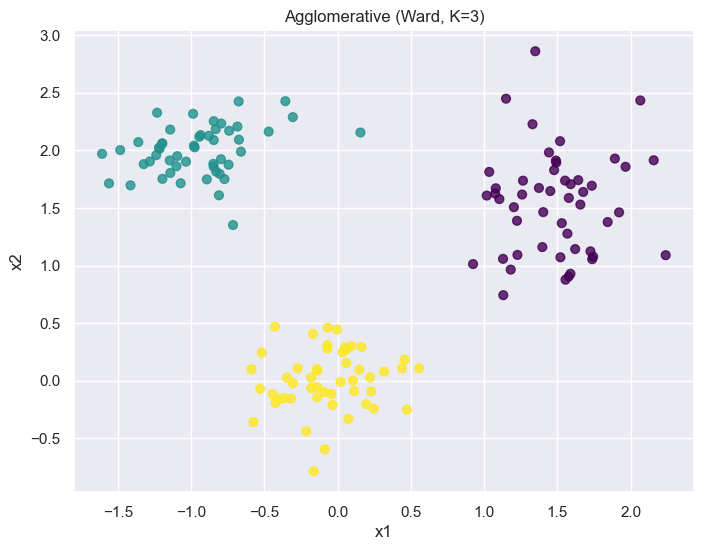

In [41]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
labels_agg = agg.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_agg, s=40, cmap='viridis', alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Agglomerative (Ward, K=3)')
plt.show()

On the three-blob data agglomerative and K-Means recover essentially the same partition. The advantage of hierarchical clustering shows up on non-convex shapes (with single linkage) and when you genuinely want a tree, not a flat partition – e.g. taxonomies, phylogenetic trees, customer segment hierarchies.

## 4. DBSCAN

**Density-Based Spatial Clustering of Applications with Noise** does what K-Means cannot:

- finds clusters of arbitrary shape (moons, spirals);
- identifies **noise points** explicitly (label `-1`);
- does not need $K$ as input.

### Core / border / noise

Pick two hyperparameters: a radius `eps` ($\varepsilon$) and a minimum count `min_samples`.

For each point $p$:

- $p$ is a **core point** if its $\varepsilon$-neighbourhood (a ball of radius $\varepsilon$ around $p$) contains at least `min_samples` points *including $p$ itself*.
- $p$ is a **border point** if it is inside some core point's $\varepsilon$-ball but is not itself a core point.
- Otherwise $p$ is **noise** (label `-1`).

A **cluster** is then the transitive closure of "lives in the same $\varepsilon$-ball as a core point".

### Algorithm

1. Pick any unvisited point. Count its $\varepsilon$-neighbours.
2. If $< \texttt{min\_samples}$, tentatively mark as noise (it may be relabelled as border later).
3. If $\geq \texttt{min\_samples}$, start a new cluster: add the point and all its neighbours; then iteratively expand by adding each newly-added neighbour's neighbours (if those neighbours are themselves core points).
4. Continue until no point can be added; pick a new unvisited point and repeat.

Interactive walkthrough: [Naftali Harris's DBSCAN visualiser](https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/).

### Picking `eps` and `min_samples`

- **`min_samples`**: a common heuristic is `2 × d` where $d$ is the dataset dimensionality (Sander et al., 1998). For 2D problems, `min_samples=4` or `5` is typical.
- **`eps`**: plot the sorted $k$-distance graph (distance to the $k$-th nearest neighbour, with $k = \texttt{min\_samples}$) and look for a knee. We'll do this on the Samsung dataset in the seminar section.

DBSCAN on blobs: 3 clusters, 1 noise points


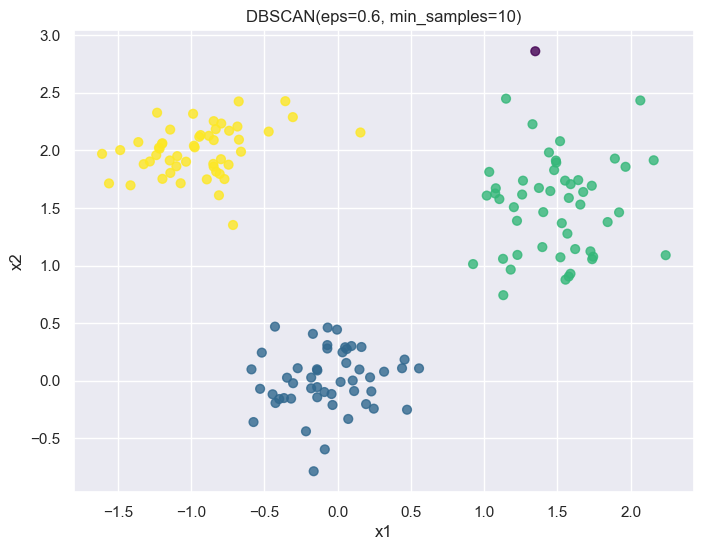

In [42]:
from sklearn.cluster import DBSCAN

# eps and min_samples picked manually here; the heuristic 2*d would give min_samples=4,
# but on three well-separated blobs we can afford a stricter density threshold.
db = DBSCAN(eps=0.6, min_samples=10).fit(X)
labels_db = db.labels_

n_noise = int((labels_db == -1).sum())
print(f'DBSCAN on blobs: {len(set(labels_db)) - (1 if -1 in labels_db else 0)} clusters, {n_noise} noise points')

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_db, cmap='viridis', s=40, alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title(f'DBSCAN(eps=0.6, min_samples=10)')
plt.show()

### DBSCAN vs K-Means on moons

This is the textbook case where DBSCAN wins.

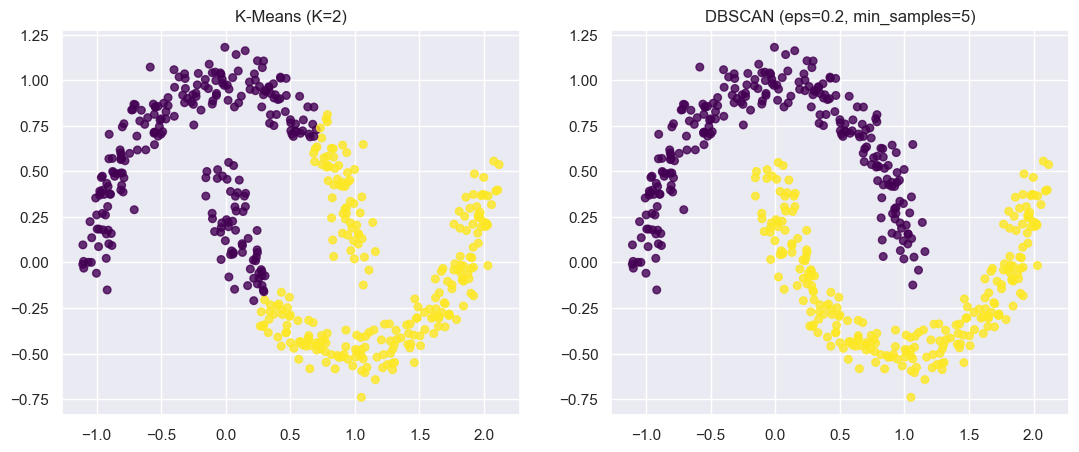

In [43]:
from sklearn.datasets import make_moons

moons, _ = make_moons(n_samples=500, noise=0.08, random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(moons)
axes[0].scatter(moons[:, 0], moons[:, 1], c=km.labels_, s=30, cmap='viridis', alpha=0.8)
axes[0].set_title('K-Means (K=2)')

db = DBSCAN(eps=0.2, min_samples=5).fit(moons)
axes[1].scatter(moons[:, 0], moons[:, 1], c=db.labels_, s=30, cmap='viridis', alpha=0.8)
axes[1].set_title(f'DBSCAN (eps=0.2, min_samples=5)')

plt.show()

K-Means cuts across the moons with a straight line; DBSCAN follows their shape because it propagates clusters along density, not along distance to a centroid.

### Sensitivity to `eps` and `min_samples`

DBSCAN's results depend strongly on these two parameters. Below: a grid over `eps` and `min_samples` on the three-blob data.

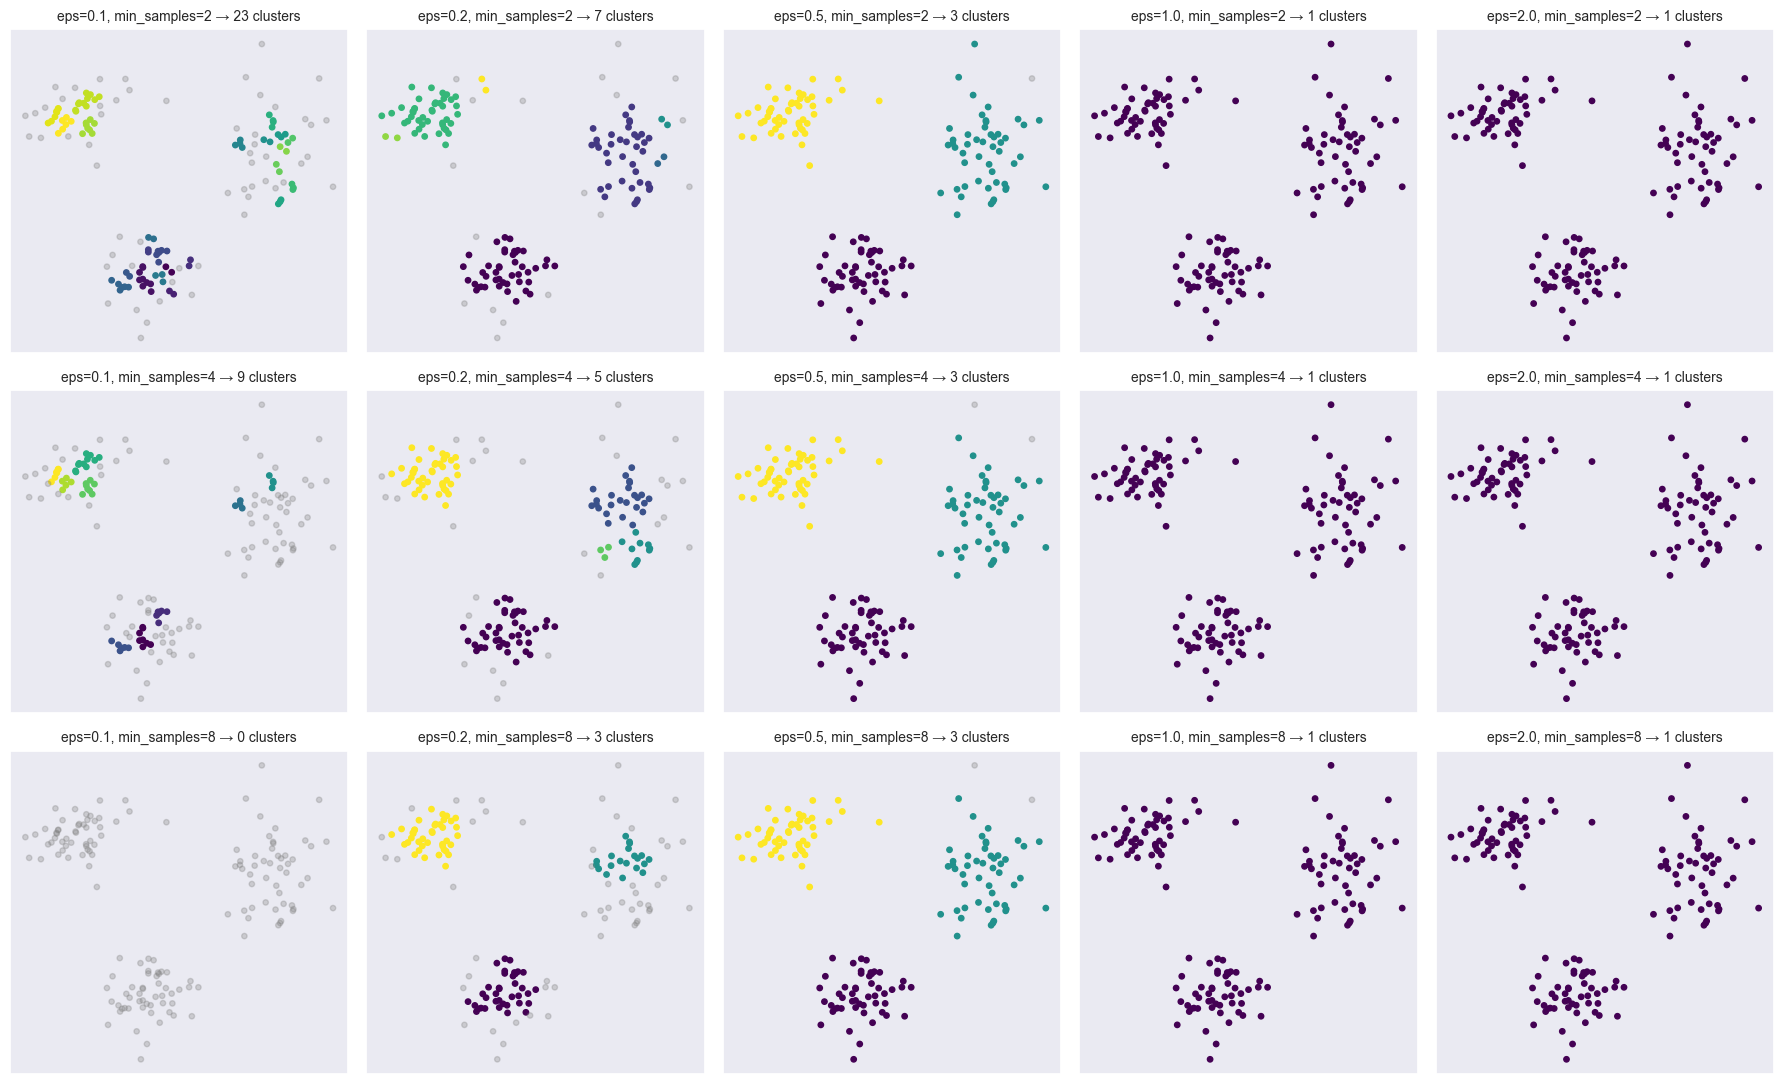

In [44]:
import matplotlib as mpl

def get_colors(clusters):
    n_clusters = len(np.unique(clusters[clusters != -1]))
    if n_clusters == 0:
        return np.tile([0.5, 0.5, 0.5, 0.3], (clusters.shape[0], 1))
    palette = mpl.colormaps['viridis'].resampled(n_clusters)(np.linspace(0, 1, n_clusters))
    colors = np.zeros((clusters.shape[0], 4))
    colors[clusters != -1] = palette[clusters[clusters != -1]]
    colors[clusters == -1] = [0.5, 0.5, 0.5, 0.3]  # grey for noise
    return colors

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
for row, samples in enumerate([2, 4, 8]):
    for col, e in enumerate([0.1, 0.2, 0.5, 1.0, 2.0]):
        ax = axes[row, col]
        clusters = DBSCAN(eps=e, min_samples=samples).fit_predict(X)
        n_clusters = len(np.unique(clusters[clusters != -1]))
        ax.scatter(X[:, 0], X[:, 1], c=get_colors(clusters), s=15)
        ax.set_title(f'eps={e}, min_samples={samples} → {n_clusters} clusters', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
plt.tight_layout()
plt.show()

Reading row by row: at fixed `min_samples`, growing `eps` first reveals the natural three clusters and then merges everything into one. Reading column by column: at fixed `eps`, growing `min_samples` declares more points as noise (grey).

> **`DBSCAN.predict` does not exist.** Unlike K-Means, DBSCAN labels only the points it was trained on – there is no function you can apply to new, unseen samples. To classify a new sample, fit a `KNeighborsClassifier` on the labelled training points and use it as a separate predictor.

### Choosing the distance metric: when Euclidean is not right

Everything so far used Euclidean distance, but for some data it is the wrong choice. Three things to know:

**1. K-Means is locked to Euclidean.** Its centroid is the *mean* of the points, which only minimises squared Euclidean distance – no other metric makes mathematical sense with the "take the mean" update step. As a result `KMeans` in sklearn simply has no `metric=` parameter. A common workaround is **K-Medoids (PAM)**: it represents each cluster by an *actual data point* from the cluster (a "medoid") instead of the mean, and so allows any distance metric. The price is that K-Medoids is much more expensive computationally and is only practical on smaller datasets. Implementation lives outside core sklearn in the third-party `scikit-learn-extra` package (`sklearn_extra.cluster.KMedoids`).

**2. DBSCAN and non-Ward AgglomerativeClustering accept custom metrics** via the `metric=` parameter (e.g. `'l1'`, `'l2'`, `'cosine'`, `'mahalanobis'`, `'precomputed'`). **Ward linkage** is also Euclidean-only because its merge formula is itself a variance update in L2.

**3. Pick the metric by what "similar" means in your data:**

| Metric | When to use |
|---|---|
| **Euclidean (`l2`)** | Default for numerical, comparably-scaled features. Used implicitly by K-Means and Ward. |
| **Manhattan (`l1`)** | More robust to outliers than L2 (linear, not quadratic, in each axis). Natural for grid-like or count data. |
| **Cosine** | Only direction matters, not magnitude. Standard for **text** (TF-IDF, embeddings) and document vectors – a long document and a short document on the same topic look similar in cosine but very different in Euclidean. |
| **Mahalanobis** | Adjusts for *correlations between features*: two features that always move together count as one direction, not two. |
| **Precomputed** | Pass your own distance matrix via `metric='precomputed'` – useful for non-Euclidean domains (string edit distance, time-series alignment, graph distances). |

**Practical rule of thumb.** If your data lives in a non-Euclidean space (text, graphs, time series with custom alignment), reach for **DBSCAN** or **hierarchical clustering with non-Ward linkage** and the matching metric – or precompute the full distance matrix and pass `metric='precomputed'`. Force-fitting K-Means with Euclidean distance on inherently non-Euclidean data is one of the most common methodological mistakes in applied clustering.

## 5. Evaluation

Unsupervised means *no labels* – so the usual `accuracy / F1 / ROC-AUC` are unavailable. Two regimes:

- **No ground truth (the realistic case)**: rely on *internal* metrics that score the geometry of the partition itself.
- **With ground truth (benchmark / sanity-check)**: use *external* metrics that compare predicted clusters to the true labels.

### Internal metrics

Two ideas: clusters should be **cohesive** (points close to their own cluster's centre) and **separated** (centres of different clusters far apart). Three commonly reported metrics that combine these ideas in different ways:

| Metric | What it measures | Range | Better |
|---|---|---|---|
| **Silhouette** | For each point: how much closer it is to its own cluster than to the nearest neighbouring cluster. Averaged over all points. | $[-1, 1]$ | higher |
| **Davies–Bouldin** | Ratio of within-cluster spread to distance between cluster centres. Averaged over the worst-matching pair for each cluster. | $[0, \infty)$ | lower |
| **Calinski–Harabasz** | Ratio of between-cluster separation to within-cluster spread. | $[0, \infty)$ | higher |

In sklearn these are `silhouette_score`, `davies_bouldin_score`, `calinski_harabasz_score`. The three usually agree on whether one partition is better than another; if they disagree, look at the data.

#### Silhouette in a bit more detail

For each point $x_i$:

- let $a$ be the mean distance from $x_i$ to the **other points in its own cluster** (cohesion);
- let $b$ be the mean distance from $x_i$ to all points in the **nearest neighbouring cluster** (separation);
- the point's silhouette is

$$s(x_i) = \frac{b - a}{\max(a, b)}$$

The dataset-level silhouette is the arithmetic mean of $s(x_i)$ over all points – exactly what `sklearn.metrics.silhouette_score` returns. Interpretation:

- $s \approx 1$ – point is much closer to its own cluster than to the next one;
- $s \approx 0$ – point sits on the boundary between two clusters;
- $s < 0$ – point is closer to a neighbouring cluster than to its own (probably misassigned).

Rule of thumb (Kaufman & Rousseeuw, 1990): silhouette above 0.5 is usually called "reasonable structure", above 0.7 – "strong structure".

In [45]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

model = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X)
print(f'Silhouette:        {silhouette_score(X, model.labels_):.3f}  (higher = better)')
print(f'Davies-Bouldin:    {davies_bouldin_score(X, model.labels_):.3f}  (lower  = better)')
print(f'Calinski-Harabasz: {calinski_harabasz_score(X, model.labels_):.1f}  (higher = better)')

Silhouette:        0.742  (higher = better)
Davies-Bouldin:    0.355  (lower  = better)
Calinski-Harabasz: 661.2  (higher = better)


**Sweep $K$ with silhouette to pick the best partition.**

In [46]:
best_k, best_score = None, -1.0
for k in range(2, 15):
    km = KMeans(n_clusters=k, n_init='auto', random_state=0).fit(X)
    score = silhouette_score(X, km.labels_)
    if score > best_score:
        best_score, best_k = score, k

print(f'Best K by silhouette: {best_k} (score = {best_score:.3f})')

Best K by silhouette: 3 (score = 0.742)


### External metrics – when ground truth is available

If you have true labels (e.g. on a benchmark dataset, or in a psychometric study where respondents have a known group), you can score how well your clustering recovers them.

- **Adjusted Rand Index (ARI)** – essentially: how often two points end up in the same cluster *and* in the same true class, beyond what you would get by random assignment. Ranges from **−1 to 1**: 0 = chance level, 1 = perfect, negative = worse than random.
- **Adjusted Mutual Information (AMI)** – information-theoretic analogue of ARI; same "adjusted for chance" idea.
- **Homogeneity** $h$ – each cluster contains members of only one class.
- **Completeness** $c$ – all members of a class end up in the same cluster.
- **V-measure** – harmonic mean of $h$ and $c$ (analogous to F1 in classification).

### Demo on `digits`

The `sklearn.datasets.load_digits` dataset is 1797 images of handwritten digits 0–9 in 8×8 grayscale = 64 features. True labels are available, so we can use both internal and external metrics.

X_dig.shape = (1797, 64)


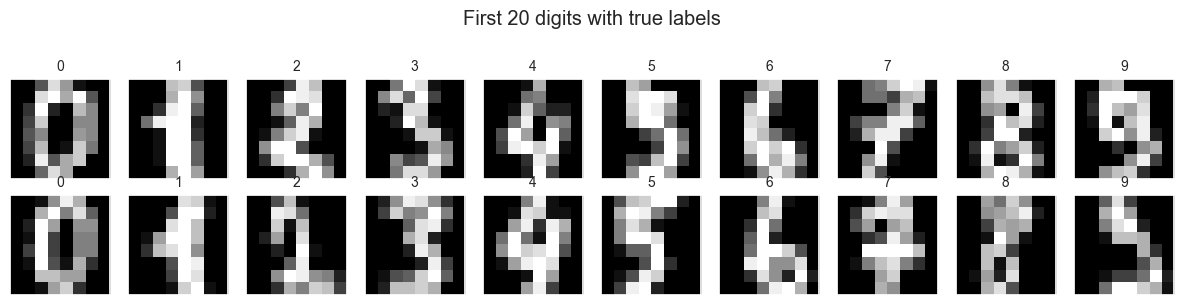

In [47]:
from sklearn.datasets import load_digits

digits = load_digits()
X_dig, y_dig = digits.data, digits.target
print(f'X_dig.shape = {X_dig.shape}')

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(str(y_dig[i]), fontsize=10)
plt.suptitle('First 20 digits with true labels', y=1.02)
plt.tight_layout()
plt.show()

In [48]:
dig_model = KMeans(n_clusters=10, n_init=10, random_state=0).fit(X_dig)

from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    homogeneity_score, completeness_score, v_measure_score,
    adjusted_rand_score, adjusted_mutual_info_score,
)

print('Internal metrics (no ground truth needed):')
print(f'  Silhouette:        {silhouette_score(X_dig, dig_model.labels_):.3f}')
print(f'  Davies-Bouldin:    {davies_bouldin_score(X_dig, dig_model.labels_):.3f}')
print(f'  Calinski-Harabasz: {calinski_harabasz_score(X_dig, dig_model.labels_):.1f}')
print()
print('External metrics (vs true digit labels):')
print(f'  Homogeneity:           {homogeneity_score(y_dig, dig_model.labels_):.3f}')
print(f'  Completeness:          {completeness_score(y_dig, dig_model.labels_):.3f}')
print(f'  V-measure:             {v_measure_score(y_dig, dig_model.labels_):.3f}')
print(f'  Adjusted Rand Index:   {adjusted_rand_score(y_dig, dig_model.labels_):.3f}')
print(f'  Adjusted Mutual Info:  {adjusted_mutual_info_score(y_dig, dig_model.labels_):.3f}')

Internal metrics (no ground truth needed):
  Silhouette:        0.183
  Davies-Bouldin:    1.925
  Calinski-Harabasz: 169.4

External metrics (vs true digit labels):
  Homogeneity:           0.738
  Completeness:          0.747
  V-measure:             0.742
  Adjusted Rand Index:   0.666
  Adjusted Mutual Info:  0.740


The internal silhouette of about 0.18 looks unimpressive in isolation. But the external metrics (homogeneity, completeness, V-measure all ≈ 0.7, ARI ≈ 0.6) show that K-Means actually recovers most of the digit structure. **Internal metrics can be misleading on high-dimensional data** – see the discussion at the end of Section 6.

**Visualise the cluster centroids as images.** Most centroids look like averaged digits, but some (e.g. 1 and 9) tend to merge because they share strokes.

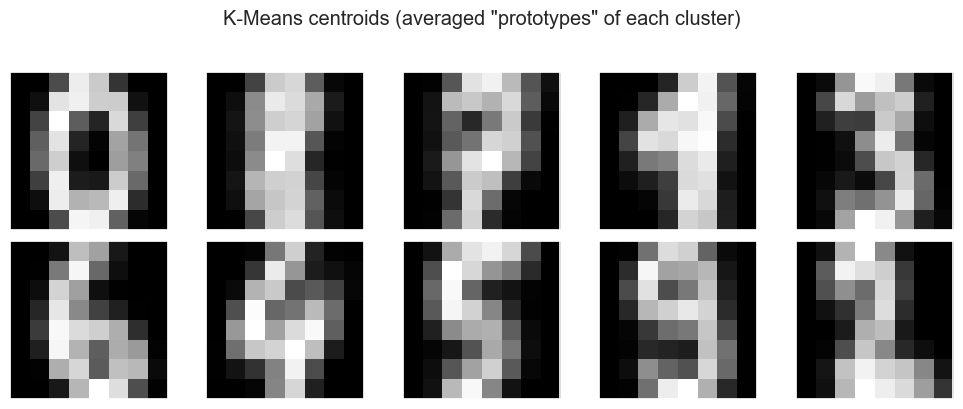

In [49]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, center in zip(axes.ravel(), dig_model.cluster_centers_):
    ax.imshow(center.reshape(8, 8), cmap='gray')
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('K-Means centroids (averaged "prototypes" of each cluster)', y=1.02)
plt.tight_layout()
plt.show()

## 6. Beyond the basics

Three extensions that show up in real ML pipelines.

### 6.1 Mini-Batch K-Means – for large datasets

Standard K-Means looks at *all* points at every iteration. On millions of points this is slow. `MiniBatchKMeans` updates the centroids from small random batches of size `batch_size`, giving essentially the same partition at a fraction of the time.

In [50]:
from sklearn.cluster import MiniBatchKMeans
import time

X_big, _ = make_blobs(n_samples=50_000, centers=8, random_state=0)

t0 = time.time()
km_full = KMeans(n_clusters=8, n_init=10, random_state=0).fit(X_big)
t_full = time.time() - t0

t0 = time.time()
km_mini = MiniBatchKMeans(n_clusters=8, batch_size=1024, n_init=10, random_state=0).fit(X_big)
t_mini = time.time() - t0

print(f'KMeans on 50k points:          {t_full:.2f} s   inertia = {km_full.inertia_:.0f}')
print(f'MiniBatchKMeans on 50k points: {t_mini:.2f} s   inertia = {km_mini.inertia_:.0f}')

KMeans on 50k points:          0.15 s   inertia = 89764
MiniBatchKMeans on 50k points: 0.02 s   inertia = 110087


Mini-batch is dramatically faster while reaching essentially the same inertia. Cost of the speed-up: slightly noisier centroid updates, so the partition can wobble between runs more than full K-Means.

### 6.2 Gaussian Mixture Models – soft clustering

K-Means makes **hard** assignments: every point belongs to exactly one cluster. A **Gaussian Mixture Model** (GMM) is more flexible: it assumes the data was generated by a mixture of bell-shaped (Gaussian) distributions and returns, for each point, a *probability* of belonging to each cluster. This is useful when boundaries are fuzzy – for example, when a survey respondent doesn't fit neatly into a single profile and you want to capture that uncertainty.

Two practical advantages over K-Means:

- **Clusters need not be round.** Each Gaussian component has its own shape, so elongated or correlated clusters fit naturally.
- **Model selection.** Use **BIC** (Bayesian Information Criterion) to compare GMMs with different numbers of components – lower BIC is better. This is a more principled alternative to staring at an elbow plot.

Soft assignment of first 3 points:
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


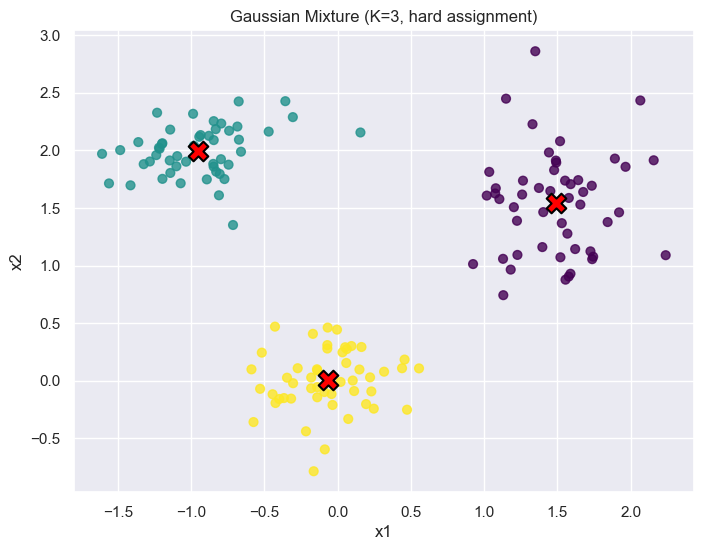

In [51]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0).fit(X)
hard_labels = gmm.predict(X)
soft_probs = gmm.predict_proba(X)
print(f'Soft assignment of first 3 points:')
print(np.round(soft_probs[:3], 3))

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=hard_labels, cmap='viridis', s=40, alpha=0.8)
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], s=200, color='red', marker='X',
            edgecolor='black', linewidth=1.5)
plt.title('Gaussian Mixture (K=3, hard assignment)')
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()

**Choosing the number of components with BIC**: lower is better. BIC penalises model complexity (number of free parameters), so it tends to favour simpler models than likelihood alone.

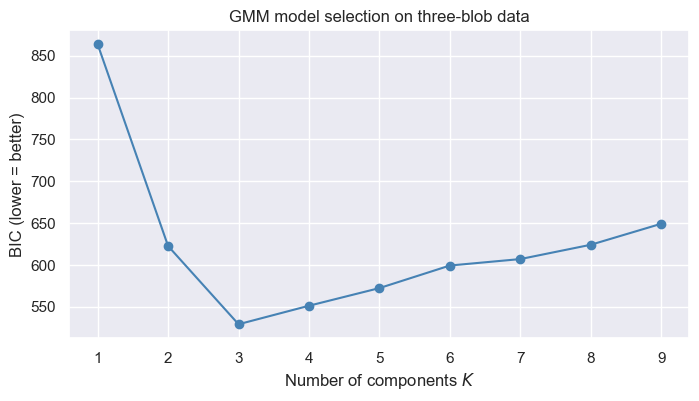

In [52]:
ks = range(1, 10)
bics = [GaussianMixture(n_components=k, random_state=0).fit(X).bic(X) for k in ks]

plt.figure(figsize=(8, 4))
plt.plot(list(ks), bics, marker='o', color='steelblue')
plt.xlabel('Number of components $K$')
plt.ylabel('BIC (lower = better)')
plt.title('GMM model selection on three-blob data')
plt.grid(True)
plt.show()

### 6.3 The curse of dimensionality

All distance-based clustering methods get worse as the number of features grows, because in very high dimensions the distance between *any* two points starts looking similar – everything is roughly equidistant from everything else. When that happens, the notion of a "cluster" stops being meaningful.

**Practical fixes**:

- **Standardise** before clustering.
- **Reduce dimensionality first** (e.g. with PCA) – exactly what we will do in the Samsung exercise below.
- **Use a domain-appropriate similarity** instead of raw Euclidean – cosine for text and embeddings, for example.

## 7. Seminar exercises – Samsung Human Activity Recognition

We end with a small end-to-end pipeline on real sensor data.

**Dataset.** Samsung Galaxy S smartphones recorded 561 accelerometer/gyroscope features from volunteers performing six daily activities. Source: [Anguita et al. (2013), "A Public Domain Dataset for Human Activity Recognition Using Smartphones"](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones). We use a re-hosted copy.

Activity labels:
1 = walking, 2 = walking upstairs, 3 = walking downstairs, 4 = sitting, 5 = standing, 6 = lying.

**Plan.** (1) load the data, (2) standardise, (3) reduce dimensionality with PCA to keep 90% of variance, (4) cluster with K-Means and agglomerative, (5) score both internally (silhouette) and externally (ARI vs the activity labels).

In [53]:
import urllib.request
from pathlib import Path

BASE = "https://raw.githubusercontent.com/juanlurg/samsung-human-activity/master/data"
data_dir = Path('samsung_data')
data_dir.mkdir(exist_ok=True)
for fname in ['samsung_train.txt', 'samsung_test.txt',
              'samsung_train_labels.txt', 'samsung_test_labels.txt']:
    fpath = data_dir / fname
    if not fpath.exists():
        urllib.request.urlretrieve(f'{BASE}/{fname}', fpath)
print('Files ready:', sorted(p.name for p in data_dir.iterdir()))

Files ready: ['samsung_test.txt', 'samsung_test_labels.txt', 'samsung_train.txt', 'samsung_train_labels.txt']


In [54]:
X_train = np.loadtxt(data_dir / 'samsung_train.txt')
y_train = np.loadtxt(data_dir / 'samsung_train_labels.txt').astype(int)
X_test = np.loadtxt(data_dir / 'samsung_test.txt')
y_test = np.loadtxt(data_dir / 'samsung_test_labels.txt').astype(int)

print(f'X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

X_train: (7352, 561)   y_train: (7352,)
X_test:  (2947, 561)   y_test:  (2947,)


### Exercise 1 – Join train and test

Clustering is unsupervised, so we don't need a train/test split. Concatenate both halves into one array.

### Exercise 2 – Inspect unique labels

### Exercise 3 – Standardise the features

### Exercise 4 – Reduce dimensionality with PCA to keep 90% of variance

A brief reminder, since we have not used PCA in this course before: **PCA (Principal Component Analysis)** finds new orthogonal axes ordered by the variance they explain. Keeping only the top components that together explain, say, 90% of variance compresses the dataset while preserving most of its information. In sklearn, `PCA(n_components=0.9)` does exactly this – picks the smallest number of components that reach the 90% cumulative-variance threshold.

From 561 raw features down to ≈ 65 PCA components – a 9× compression that preserves most of the variance. The few dozen retained components are exactly what we will cluster on.

### Exercise 5 – Visualise the first two principal components, coloured by true activity

Even in 2D the moving activities (1, 2, 3) and the static ones (4, 5, 6) form two visually separated mega-clusters – a sign that the dataset is "cluster-friendly" in PCA space.

### Exercise 6 – K-Means with the number of clusters equal to the number of activities

### Exercise 7 – Re-visualise with predicted cluster colours

### Exercise 8 – Report internal + external metrics for K-Means

### Exercise 9 – Repeat with agglomerative (Ward) clustering and compare

### Exercise 10 – Confusion matrix between true activities and predicted clusters

Clusters are labelled by arbitrary integers – they don't directly correspond to activity IDs. A confusion-style cross-tabulation lets us see which activities get merged into which cluster.

**Reading the matrix.** Each row should ideally concentrate in one cluster (high homogeneity). In practice some activities are easily separated (lying is its own cluster, walking up/down often form a single "moving" cluster). This is exactly what the silhouette/ARI numbers above quantify.

### Reflection questions

- Both K-Means and agglomerative are *flat* clusterers given $K$. Would DBSCAN help here? Try `eps` around the median 1-nearest-neighbour distance and report results.
- The dataset contains six activities, but maybe a 3-cluster solution (lying / sitting-standing / walking-variants) is more natural. Re-run with $K=3$ and compare silhouette: does internal-metric ranking match human intuition?
- If we had only the unlabelled signals (no activity tags) and silhouette $\approx 0.2$, would we trust K-Means here? What would change our mind?